# FX Desk Analytics

Analysis of client trading behaviour and profitability for an FX brokerage,
based on daily prices for 4 instruments and 3,000 trade records (Jul 2025 – Jun 2026).

*วิเคราะห์พฤติกรรมการเทรดและผลตอบแทนของลูกค้า FX brokerage
จากข้อมูลราคา 4 คู่เงิน และรายการเทรด 3,000 รายการ (ก.ค. 2025 - มิ.ย. 2026)*

**Questions answered / คำถามที่ตอบ**
- Which instrument generates the most profit for clients, and how volatile is it?
  *คู่เงินไหนสร้างกำไรให้ลูกค้ามากที่สุด และผันผวนแค่ไหน*
- How do results differ by client country and account type?
  *ลูกค้าประเทศไหน / ประเภทบัญชีไหน ทำผลงานต่างกันอย่างไร*
- Does lot size have a statistically significant effect on profit?
  *ขนาด lot มีผลต่อกำไรอย่างมีนัยสำคัญทางสถิติหรือไม่*

**Project structure / โครงสร้างโปรเจกต์**

    data/raw/          raw source files          ข้อมูลต้นฉบับ
    data/processed/    cleaned data (parquet)    ข้อมูลที่ทำความสะอาดแล้ว
    charts/            exported figures          กราฟที่ส่งออก
    fx_utils.py        reusable functions        ฟังก์ชันที่ใช้ซ้ำ
    report.xlsx        summary for management    ตารางสรุปสำหรับผู้บริหาร

## 1. Data Loading and Exploration

Load all three source files through `load_data()` in `fx_utils.py`,
then inspect structure, data types and basic distributions.

*โหลดข้อมูลทั้ง 3 ไฟล์ผ่านฟังก์ชัน `load_data()` ใน `fx_utils.py`
แล้วสำรวจโครงสร้าง ชนิดข้อมูล และการกระจายเบื้องต้น*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from pathlib import Path

from fx_utils import load_data, add_indicators, data_quality_report

In [2]:
clients, trades, fx_daily = load_data()

print(f"\nclients df = {clients.shape}")
clients.info()
print(f"\ntrades df = {trades.shape}")
trades.info()
print(f"\nfx_daily df = {fx_daily.shape}")
fx_daily.info()


clients df = (200, 5)
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   client_id     200 non-null    int64         
 1   country       200 non-null    str           
 2   account_type  200 non-null    str           
 3   join_date     200 non-null    datetime64[us]
 4   deposit_usd   200 non-null    int64         
dtypes: datetime64[us](1), int64(2), str(2)
memory usage: 11.3 KB

trades df = (3000, 7)
<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   trade_id    3000 non-null   int64         
 1   date        3000 non-null   datetime64[us]
 2   client_id   3000 non-null   int64         
 3   pair        3000 non-null   str           
 4   side        3000 non-null   str           
 5   lots     

In [3]:
print(f"\ntrades df\n{trades['profit_usd'].describe()}")
print(f"\nclient df by country\n{clients['country'].value_counts()}")
print(f"\ntrade df by pair\n{trades['pair'].value_counts()}")


trades df
count    3000.000000
mean        5.753733
std        57.524627
min      -410.870000
25%        -2.092500
50%         0.530000
75%         6.462500
max       611.450000
Name: profit_usd, dtype: float64

client df by country
country
Malaysia       50
Thailand       49
Indonesia      34
Vietnam        29
Singapore      21
Philippines    17
Name: count, dtype: int64

trade df by pair
pair
XAUUSD    771
EURUSD    757
GBPUSD    752
USDJPY    720
Name: count, dtype: int64


## 2. Filtering and Selection

Filter the data under various conditions to isolate the subsets of interest.

*กรองข้อมูลตามเงื่อนไขต่าง ๆ เพื่อดูกลุ่มย่อยที่สนใจ*

In [4]:
print(f"\n{trades[trades['profit_usd'] > 0]}")
print(f"\n{trades[(trades['pair'] == 'XAUUSD') & (trades['lots'] >= 1.0)]}")
print(f"\n{clients[clients['country'].isin(['Thailand', 'Malaysia'])]}")
print(f"\n{trades.nlargest(10, 'profit_usd')}")
print(f"\n{fx_daily[(fx_daily['pair'] == 'EURUSD') & (fx_daily['date'].dt.year == 2026) & (fx_daily['date'].dt.month == 1)]}")


      trade_id       date  client_id    pair  side  lots  profit_usd
0         2905 2025-07-01         89  XAUUSD   buy  1.00       74.97
1         1713 2025-07-01         27  EURUSD   buy  2.00       69.01
2          730 2025-07-01         58  GBPUSD  sell  0.05        0.17
3         2438 2025-07-01        197  EURUSD  sell  1.00      241.01
4         2623 2025-07-01          9  EURUSD   buy  0.10        1.18
...        ...        ...        ...     ...   ...   ...         ...
2992      2467 2026-06-30        120  XAUUSD   buy  0.50       97.86
2993       739 2026-06-30         40  XAUUSD   buy  0.10       24.30
2995      1903 2026-06-30        102  EURUSD   buy  0.01        1.05
2996      1784 2026-06-30        100  USDJPY  sell  0.05        0.78
2997        31 2026-06-30        144  GBPUSD   buy  0.01        0.95

[1734 rows x 7 columns]

      trade_id       date  client_id    pair  side  lots  profit_usd
0         2905 2025-07-01         89  XAUUSD   buy   1.0       74.97
14     

## 3. Grouping and Aggregation

Summarise results by instrument and trade direction (buy/sell), and add columns
comparing each individual trade against the average of its own instrument.

*สรุปผลตามคู่เงินและทิศทางการเทรด (buy/sell)
รวมถึงสร้างคอลัมน์เปรียบเทียบรายเทรดกับค่าเฉลี่ยของคู่เงินตัวเอง*

In [5]:
trades.groupby("pair")["profit_usd"].sum()

pair
EURUSD    5148.46
GBPUSD    4741.21
USDJPY    3867.33
XAUUSD    3504.20
Name: profit_usd, dtype: float64

In [6]:
trades.groupby("pair").agg(
    total_profit = ("profit_usd", "sum"),
    avg_profit = ("profit_usd", "mean"),
    total_trades = ("profit_usd", "count"),
    total_lots = ("lots", "sum")
).sort_values(["total_lots", "total_trades"], ascending=[False, True])

,total_profit,avg_profit,total_trades,total_lots
pair,,,,
XAUUSD,3504.20,4.545006,771,252.96
USDJPY,3867.33,5.371292,720,237.32
EURUSD,5148.46,6.801136,757,232.64
GBPUSD,4741.21,6.304801,752,226.86


In [7]:
trades.groupby(["pair", "side"])["profit_usd"].mean()

pair    side
EURUSD  buy     7.121931
        sell    6.481187
GBPUSD  buy     4.700273
        sell    7.826192
USDJPY  buy     1.394448
        sell    8.831662
XAUUSD  buy     3.477220
        sell    5.757729
Name: profit_usd, dtype: float64

In [8]:
trades.pivot_table(index="pair", columns="side", values="profit_usd", aggfunc="mean")

side,buy,sell
pair,,
EURUSD,7.121931,6.481187
GBPUSD,4.700273,7.826192
USDJPY,1.394448,8.831662
XAUUSD,3.477220,5.757729


In [9]:
trades["pair_avg"] = trades.groupby("pair")["profit_usd"].transform("mean")
trades["vs_avg"] = trades["profit_usd"] - trades["pair_avg"]
trades.head()

,trade_id,date,client_id,pair,side,lots,profit_usd,pair_avg,vs_avg
0,2905,2025-07-01,89,XAUUSD,buy,1.00,74.97,4.545006,70.424994
1,1713,2025-07-01,27,EURUSD,buy,2.00,69.01,6.801136,62.208864
2,730,2025-07-01,58,GBPUSD,sell,0.05,0.17,6.304801,-6.134801
3,2438,2025-07-01,197,EURUSD,sell,1.00,241.01,6.801136,234.208864
4,2623,2025-07-01,9,EURUSD,buy,0.10,1.18,6.801136,-5.621136


In [10]:
for pair, group in trades.groupby("pair"):
    print(pair, len(group))

EURUSD 757
GBPUSD 752
USDJPY 720
XAUUSD 771


## 4. Merging Tables

Join trade records with client details, then join to market prices
using a composite key of date + pair.

*เชื่อมข้อมูลเทรดเข้ากับข้อมูลลูกค้า และเชื่อมกับราคาตลาดด้วยคีย์ date + pair*

In [11]:
df = trades.merge(clients, on="client_id", how="left")
df.head(10)

,trade_id,date,client_id,pair,side,lots,profit_usd,pair_avg,vs_avg,country,account_type,join_date,deposit_usd
0,2905,2025-07-01,89,XAUUSD,buy,1.00,74.97,4.545006,70.424994,Vietnam,Standard,2025-08-28,500
1,1713,2025-07-01,27,EURUSD,buy,2.00,69.01,6.801136,62.208864,Thailand,cTrader,2026-05-18,2500
2,730,2025-07-01,58,GBPUSD,sell,0.05,0.17,6.304801,-6.134801,Thailand,Standard,2025-09-06,500
3,2438,2025-07-01,197,EURUSD,sell,1.00,241.01,6.801136,234.208864,Singapore,Standard,2025-08-08,5000
4,2623,2025-07-01,9,EURUSD,buy,0.10,1.18,6.801136,-5.621136,Malaysia,Raw Spread,2026-05-21,1000
5,2999,2025-07-01,126,EURUSD,sell,0.10,-16.06,6.801136,-22.861136,Thailand,Standard,2026-01-25,500
6,316,2025-07-01,127,GBPUSD,sell,0.10,9.45,6.304801,3.145199,Philippines,Standard,2025-09-13,500
7,2389,2025-07-01,84,USDJPY,sell,0.10,7.56,5.371292,2.188708,Philippines,Raw Spread,2025-12-25,500
8,1607,2025-07-01,180,EURUSD,sell,0.01,-1.03,6.801136,-7.831136,Thailand,Raw Spread,2026-04-30,500
9,207,2025-07-01,51,USDJPY,buy,0.05,-4.38,5.371292,-9.751292,Philippines,cTrader,2025-10-29,500


In [12]:
df.groupby("account_type")["profit_usd"].mean()

account_type
Raw Spread    6.351820
Standard      5.623302
cTrader       4.825645
Name: profit_usd, dtype: float64

In [13]:
df.groupby(["country", "account_type"])["profit_usd"].sum()

country      account_type
Indonesia    Raw Spread      3045.24
             Standard        1052.99
             cTrader           90.99
Malaysia     Raw Spread      1116.95
             Standard        2798.11
             cTrader          504.71
Philippines  Raw Spread       651.72
             Standard         350.14
             cTrader          400.94
Singapore    Raw Spread       742.91
             Standard        1212.99
             cTrader          -45.96
Thailand     Raw Spread       378.19
             Standard        1782.97
             cTrader         1437.97
Vietnam      Raw Spread       766.16
             Standard        1080.30
             cTrader         -106.12
Name: profit_usd, dtype: float64

In [14]:
df.pivot_table(index="country", columns="account_type", values="profit_usd", aggfunc="sum")

account_type,Raw Spread,Standard,cTrader
country,,,
Indonesia,3045.24,1052.99,90.99
Malaysia,1116.95,2798.11,504.71
Philippines,651.72,350.14,400.94
Singapore,742.91,1212.99,-45.96
Thailand,378.19,1782.97,1437.97
Vietnam,766.16,1080.30,-106.12


In [15]:
pd.crosstab(df["country"], df["pair"])

pair,EURUSD,GBPUSD,USDJPY,XAUUSD
country,,,,
Indonesia,133,123,111,121
Malaysia,185,181,178,193
Philippines,71,75,73,77
Singapore,80,88,76,81
Thailand,188,183,178,181
Vietnam,100,102,104,118


In [16]:
pd.merge(df, fx_daily, on=["date", "pair"])

,trade_id,date,client_id,pair,side,lots,profit_usd,pair_avg,vs_avg,country,account_type,join_date,deposit_usd,open,high,low,close,volume
0,2905,2025-07-01,89,XAUUSD,buy,1.00,74.97,4.545006,70.424994,Vietnam,Standard,2025-08-28,500,2380.00000,2391.76938,2364.57091,2378.17014,19154
1,1713,2025-07-01,27,EURUSD,buy,2.00,69.01,6.801136,62.208864,Thailand,cTrader,2026-05-18,2500,1.08500,1.08784,1.08260,1.08522,58381
2,730,2025-07-01,58,GBPUSD,sell,0.05,0.17,6.304801,-6.134801,Thailand,Standard,2025-09-06,500,1.27000,1.26847,1.26336,1.26591,8468
3,2438,2025-07-01,197,EURUSD,sell,1.00,241.01,6.801136,234.208864,Singapore,Standard,2025-08-08,5000,1.08500,1.08784,1.08260,1.08522,58381
4,2623,2025-07-01,9,EURUSD,buy,0.10,1.18,6.801136,-5.621136,Malaysia,Raw Spread,2026-05-21,1000,1.08500,1.08784,1.08260,1.08522,58381
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,1903,2026-06-30,102,EURUSD,buy,0.01,1.05,6.801136,-5.751136,Thailand,Raw Spread,2026-01-13,500,0.96198,0.96446,0.96018,0.96232,43854
2996,1784,2026-06-30,100,USDJPY,sell,0.05,0.78,5.371292,-4.591292,Thailand,cTrader,2026-04-23,1000,168.56463,169.27669,168.08074,168.67871,13723
2997,31,2026-06-30,144,GBPUSD,buy,0.01,0.95,6.304801,-5.354801,Malaysia,cTrader,2026-03-03,500,1.33665,1.33893,1.33691,1.33792,8143
2998,1282,2026-06-30,56,USDJPY,sell,0.10,-0.62,5.371292,-5.991292,Malaysia,Raw Spread,2026-04-10,500,168.56463,169.27669,168.08074,168.67871,13723


## 5. Time Series Analysis

Compute daily returns, a 20-day moving average and 20-day volatility for EURUSD,
then resample to monthly frequency to see the trend.

*คำนวณผลตอบแทนรายวัน ค่าเฉลี่ยเคลื่อนที่ 20 วัน และความผันผวน 20 วันของ EURUSD
แล้วยุบข้อมูลเป็นรายเดือนเพื่อดูแนวโน้ม*

In [17]:
fx_eurusd = fx_daily[fx_daily["pair"] == "EURUSD"].set_index("date")
fx_eurusd["ret"] = fx_eurusd["close"].pct_change()
fx_eurusd["ma20"] = fx_eurusd["close"].rolling(20).mean()
fx_eurusd["vol20"] = fx_eurusd["ret"].rolling(20).std()
fx_eurusd.head()

,pair,open,high,low,close,volume,ret,ma20,vol20
date,,,,,,,,,
2025-07-01,EURUSD,1.08500,1.08784,1.08260,1.08522,58381,NaN,NaN,NaN
2025-07-02,EURUSD,1.08522,1.08854,1.08493,1.08674,47450,0.001401,NaN,NaN
2025-07-03,EURUSD,1.08674,1.08646,1.08506,1.08576,26137,-0.000902,NaN,NaN
2025-07-04,EURUSD,1.08576,1.08550,1.07873,1.08211,44026,-0.003362,NaN,NaN
2025-07-07,EURUSD,1.08211,1.08202,1.07870,1.08036,49365,-0.001617,NaN,NaN


In [18]:
# monthly close
fx_eurusd["close"].resample("ME").last()

date
2025-07-31    1.04849
2025-08-31    1.02326
2025-09-30    1.03640
2025-10-31    1.03872
2025-11-30    1.03521
2025-12-31    1.01405
2026-01-31    1.01080
2026-02-28    0.99288
2026-03-31    1.00277
2026-04-30    1.01221
2026-05-31    0.99098
2026-06-30    0.96232
Freq: ME, Name: close, dtype: float64

In [19]:
trades_dateindex = trades.set_index("date")
trades_dateindex["profit_usd"].resample("ME").sum()

date
2025-07-31    1885.02
2025-08-31     409.47
2025-09-30    1458.37
2025-10-31    1819.80
2025-11-30    1317.73
2025-12-31     457.03
2026-01-31     815.84
2026-02-28     838.99
2026-03-31    1269.13
2026-04-30    3453.27
2026-05-31    2418.42
2026-06-30    1118.13
Freq: ME, Name: profit_usd, dtype: float64

## 6. Visualization

Produce four figures and save them as PNG files in `charts/` for use in the README.

*สร้างกราฟ 4 รูปและบันทึกเป็นไฟล์ PNG ลงโฟลเดอร์ `charts/` เพื่อใช้ใน README*

In [20]:
df33 = df.pivot_table(index="country", columns="account_type",
                      values="profit_usd", aggfunc="sum")
by_country = df33
df33

account_type,Raw Spread,Standard,cTrader
country,,,
Indonesia,3045.24,1052.99,90.99
Malaysia,1116.95,2798.11,504.71
Philippines,651.72,350.14,400.94
Singapore,742.91,1212.99,-45.96
Thailand,378.19,1782.97,1437.97
Vietnam,766.16,1080.30,-106.12


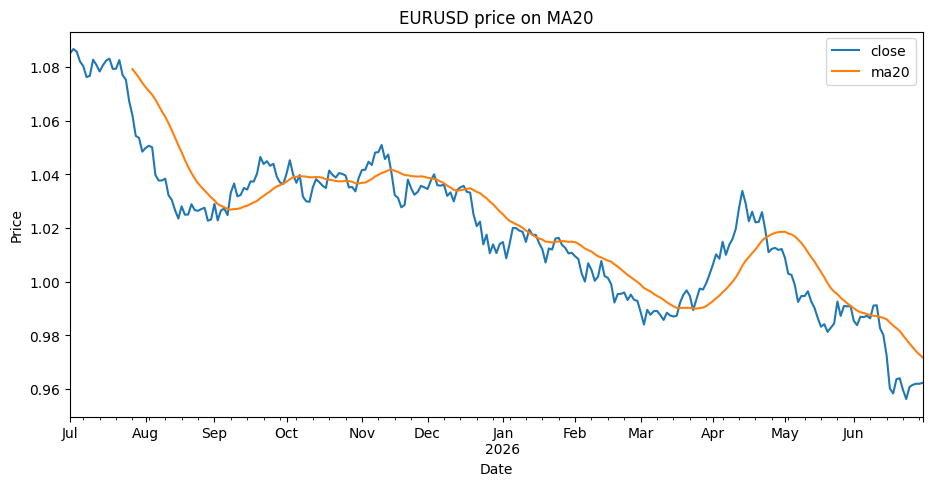

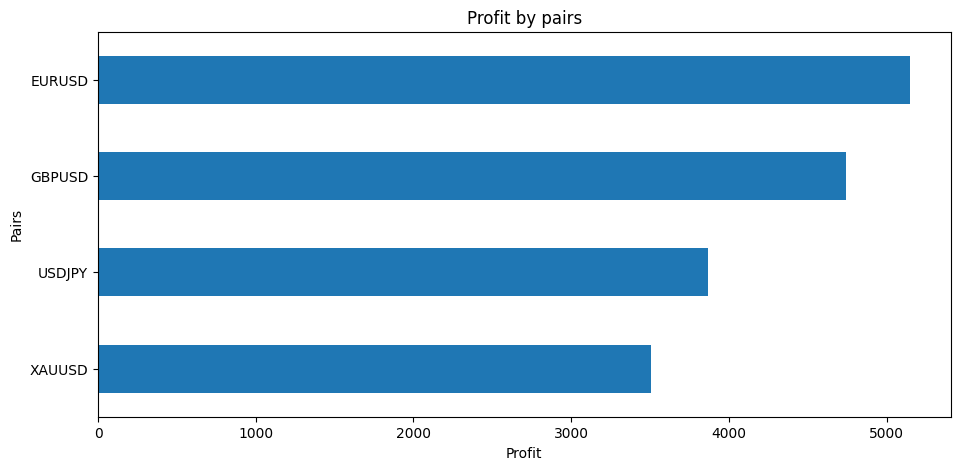

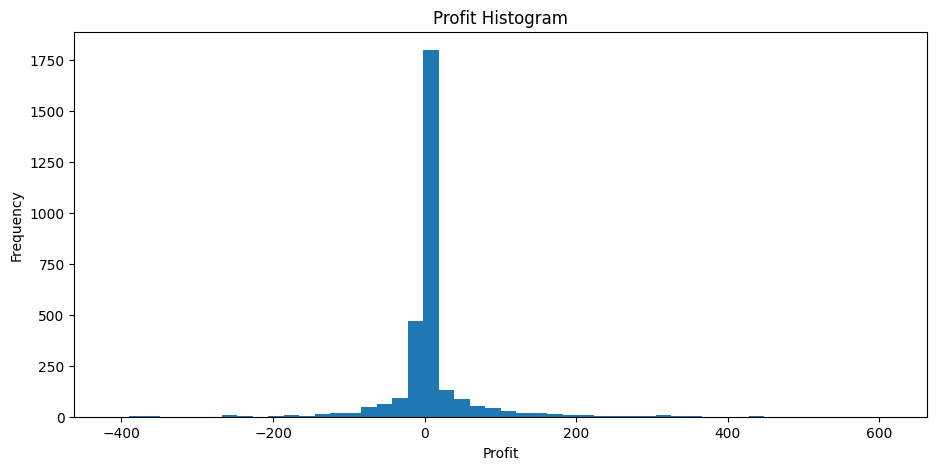

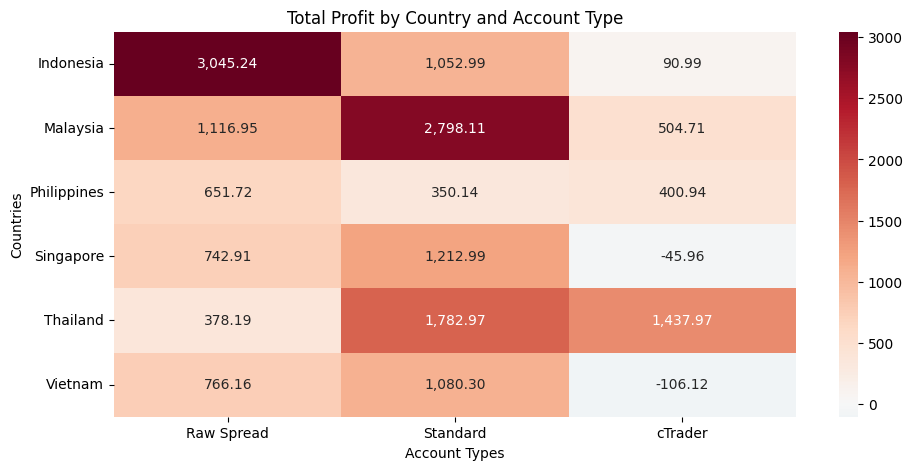

In [21]:
from pathlib import Path
import matplotlib.pyplot as plt

Path("charts").mkdir(exist_ok=True)

fig, ax = plt.subplots(figsize=(11,5))
fx_eurusd[["close", "ma20"]].plot(ax=ax)
ax.set_title("EURUSD price on MA20")
ax.set_xlabel("Date")
ax.set_ylabel("Price")
fig.savefig("charts/price_ma.png", dpi=150, bbox_inches="tight")


fig, ax = plt.subplots(figsize=(11,5))
trades.groupby("pair")["profit_usd"].sum().sort_values(ascending=True).plot(kind="barh", ax=ax)
ax.set_title("Profit by pairs")
ax.set_xlabel("Profit")
ax.set_ylabel("Pairs")
fig.savefig("charts/profit_by_pairs.png", dpi=150, bbox_inches="tight")


fig, ax = plt.subplots(figsize=(11,5))
trades["profit_usd"].plot(kind="hist", bins=50, ax=ax)
ax.set_title("Profit Histogram")
ax.set_xlabel("Profit")
ax.set_ylabel("Frequency")
fig.savefig("charts/profit_hist.png", dpi=150, bbox_inches="tight")


fig, ax = plt.subplots(figsize=(11,5))
sns.heatmap(by_country, annot=True, fmt=",.02f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Total Profit by Country and Account Type")
ax.set_xlabel("Account Types")
ax.set_ylabel("Countries")
fig.savefig("charts/heatmap_country.png", dpi=150, bbox_inches="tight")

## 7. Statistical Model

Use OLS regression to test whether lot size and account type have a
statistically significant effect on profit.

*ใช้ OLS regression ตรวจว่าขนาด lot และประเภทบัญชีมีผลต่อกำไรอย่างมีนัยสำคัญหรือไม่*

In [22]:
import statsmodels.formula.api as smf
m = smf.ols("profit_usd ~ lots + account_type", data=df).fit()
pd.DataFrame({"coef": m.params.round(4), "p_value": m.pvalues.round(4)})

,coef,p_value
Intercept,-0.0565,0.9759
account_type[T.Standard],-0.5383,0.8139
account_type[T.cTrader],-1.8576,0.5537
lots,20.1118,0.0000


### Model Findings / สรุปผลโมเดล

**Position size is the only statistically significant variable** (p < 0.001).
Each additional lot is associated with roughly 20 USD more profit on average.

*ขนาดของ position เป็นตัวแปรเดียวที่มีนัยสำคัญทางสถิติ (p < 0.001)
โดยทุก 1 lot ที่เพิ่มขึ้น กำไรเฉลี่ยเพิ่มขึ้นประมาณ 20 USD*

**Account type shows no conclusive effect on profit.** Both Standard and cTrader
have p-values above 0.5 relative to the Raw Spread baseline, meaning the observed
differences are consistent with random variation.

*ส่วนประเภทบัญชียังสรุปไม่ได้ว่ามีผลต่อกำไร — ทั้ง Standard และ cTrader
มี p-value สูงกว่า 0.5 เมื่อเทียบกับ Raw Spread ซึ่งหมายความว่าความต่างที่เห็น
ในข้อมูลอธิบายได้ด้วยความบังเอิญ*

**Business implication:** client profitability is driven primarily by trade size,
not by the account type they choose. Revenue efforts should therefore focus on
clients who trade larger sizes rather than on migrating clients between account types.

*ในทางธุรกิจ: ผลกำไรของลูกค้าขึ้นกับขนาดที่เทรดเป็นหลัก ไม่ใช่ประเภทบัญชีที่เลือก
การจะเพิ่มรายได้จึงควรโฟกัสที่กลุ่มลูกค้าที่เทรดขนาดใหญ่
มากกว่าการผลักดันให้ย้ายประเภทบัญชี*

## 8. Data Quality Checks and Export

Validate the data with `assert` statements, then export results as Excel
(for management) and Parquet (for downstream use).

*ตรวจสอบความถูกต้องของข้อมูลด้วย `assert` แล้วส่งออกผลลัพธ์
เป็นไฟล์ Excel (สำหรับผู้บริหาร) และ Parquet (สำหรับนำไปใช้ต่อ)*

In [23]:
assert len(df) == 3000, f"merge ทำให้แถวเปลี่ยน: ได้ {len(df)}"
assert fx_eurusd["close"].isna().sum() == 0, "ยังมี NaN ใน close"
assert trades["pair"].nunique() == 4, f"ควรมี 4 คู่เงิน แต่ได้ {trades['pair'].nunique()}"

In [24]:
data_quality_report(df)

,Total NaN,Unique
trade_id,0,3000
date,0,261
client_id,0,200
pair,0,4
side,0,2
lots,0,6
profit_usd,0,1975
pair_avg,0,4
vs_avg,0,2551
country,0,6


In [25]:
summary_by_pair = trades.groupby("pair").agg(
    total_profit = ("profit_usd", "sum"),
    avg_profit = ("profit_usd", "mean"),
    total_trades = ("profit_usd", "count"),
    total_lots = ("lots", "sum")
).sort_values(["total_lots", "total_trades"], ascending=[False, True])

by_country = df.pivot_table(index="country", columns="account_type", values="profit_usd", aggfunc="sum")

monthly = trades_dateindex["profit_usd"].resample("ME").sum()


with pd.ExcelWriter("report.xlsx") as writer:
    summary_by_pair.to_excel(writer, sheet_name="summary_by_pair")
    by_country.to_excel(writer, sheet_name="by_country")
    monthly.to_excel(writer, sheet_name="monthly")

In [26]:
Path("data/processed").mkdir(parents=True, exist_ok=True)

df.to_parquet("data/processed/trades_enriched.parquet")
fx_eurusd.to_parquet("data/processed/fx_eurusd.parquet")

print(pd.read_parquet("data/processed/trades_enriched.parquet").dtypes)
print()
print(pd.read_parquet("data/processed/fx_eurusd.parquet").dtypes)

trade_id                 int64
date            datetime64[us]
client_id                int64
pair                       str
side                       str
lots                   float64
profit_usd             float64
pair_avg               float64
vs_avg                 float64
country                    str
account_type               str
join_date       datetime64[us]
deposit_usd              int64
dtype: object

pair          str
open      float64
high      float64
low       float64
close     float64
volume      int64
ret       float64
ma20      float64
vol20     float64
dtype: object
